In [ ]:
from google.colab import drive
import pandas as pd

# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and pipelines
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Model selection and evaluation tools
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold, learning_curve
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)

# Models
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier


# Model persistence
import joblib

# Timing
import time


In [ ]:
df = pd.read_csv('/content/test_data.csv')
df.head()

,Gender,Age,Debt,Marital Status,Education Level,Occupation,Employer,Years Employed,Prior Default,Employed,Credit Score,Citizen,Type of Housing,Savings,Current Balance,Approval
0,0,20.67,1.250,1,1,6,1,1.375,0,0,3,1,0,140.0,210,0
1,0,29.50,0.580,0,0,0,0,0.290,1,0,1,0,0,340.0,2803,0
2,1,35.42,12.000,0,0,1,1,14.000,0,0,8,0,0,0.0,6590,1
3,0,20.00,7.000,0,0,6,0,0.500,1,1,0,0,0,0.0,0,0
4,1,21.92,11.665,0,0,5,1,0.085,1,1,0,0,0,320.0,5,0


In [ ]:
X_test = df.drop(columns='Approval').values.astype(np.float32)
y_test = df['Approval'].values.astype(np.float32)

In [ ]:
mlp_model = joblib.load('/content/best_mlp_model.pkl')

In [ ]:
svm_model = joblib.load('/content/best_svm_model.pkl')

In [ ]:
y_pred = mlp_model.predict(X_test)
y_pred_svm = svm_model.predict(X_test)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


In [ ]:
y_prob_mlp = mlp_model.predict_proba(X_test)[:, 1]
y_prob_svm = svm_model.decision_function(X_test)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

         0.0       0.86      0.89      0.88        76
         1.0       0.85      0.80      0.82        55

    accuracy                           0.85       131
   macro avg       0.85      0.85      0.85       131
weighted avg       0.85      0.85      0.85       131



In [ ]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

         0.0       0.94      0.78      0.85        76
         1.0       0.75      0.93      0.83        55

    accuracy                           0.84       131
   macro avg       0.84      0.85      0.84       131
weighted avg       0.86      0.84      0.84       131



In [ ]:
# Printing the perofrmance metrics

from sklearn.metrics import precision_recall_fscore_support, accuracy_score

precision_mlp, recall_mlp, f1_mlp, _ = precision_recall_fscore_support(y_test, y_pred, average = 'binary')
accuracy_mlp = accuracy_score(y_test, y_pred)

print('MLP Performance: ')
print(f'Accuracy: {accuracy_mlp:.4f}')
print(f'Precision: {precision_mlp:.4f}')
print(f'Recall: {recall_mlp:.4f}')
print(f'F1 Score: {f1_mlp:.4f}')

MLP Performance: 
Accuracy: 0.8550
Precision: 0.8462
Recall: 0.8000
F1 Score: 0.8224


In [ ]:
precision_svm, recall_svm, f1_svm, _ = precision_recall_fscore_support(y_test, y_pred_svm, average = 'binary')
accuracy_svm = accuracy_score(y_test, y_pred_svm)

print('SVM Performance: ')
print(f'Accuracy: {accuracy_svm:.4f}')
print(f'Precision: {precision_svm:.4f}')
print(f'Recall: {recall_svm:.4f}')
print(f'F1 Score: {f1_svm:.4f}')

SVM Performance: 
Accuracy: 0.8397
Precision: 0.7500
Recall: 0.9273
F1 Score: 0.8293


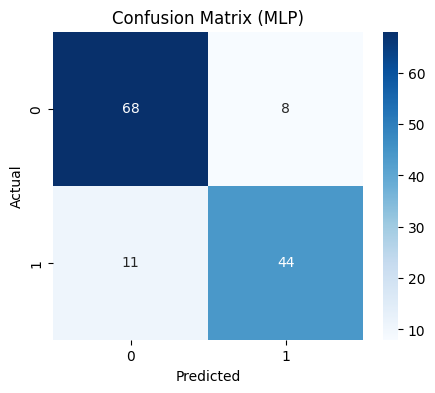

In [ ]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

conf_mat_mlp = confusion_matrix(y_test, y_pred)
plt.figure(figsize = (5, 4))
sns.heatmap(conf_mat_mlp, annot = True, fmt = 'd', cmap = 'Blues')
plt.title('Confusion Matrix (MLP)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

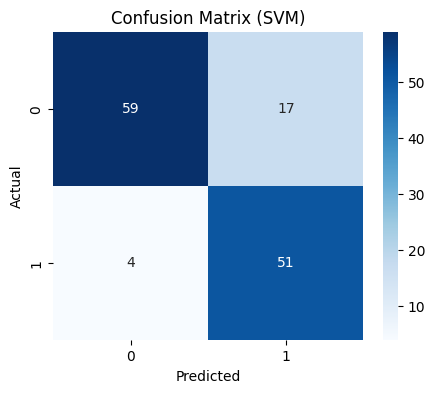

In [ ]:
conf_mat_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize = (5, 4))
sns.heatmap(conf_mat_svm, annot = True, fmt = 'd', cmap = 'Blues')
plt.title('Confusion Matrix (SVM)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

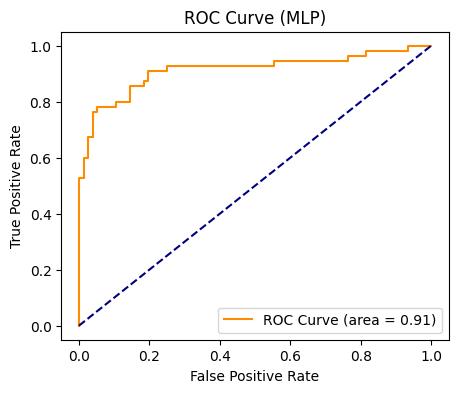

In [ ]:
# ROC AUC Curve

from sklearn.metrics import roc_curve, auc

fpr_mlp, tpr_mlp, _ = roc_curve(y_test, y_prob_mlp)
roc_auc_mlp = auc(fpr_mlp, tpr_mlp)

plt.figure(figsize = (5, 4))
plt.plot(fpr_mlp, tpr_mlp, color = 'darkorange', label = f'ROC Curve (area = {roc_auc_mlp:.2f})')
plt.plot([0, 1], [0, 1], color = 'navy', linestyle = '--')
plt.title('ROC Curve (MLP)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

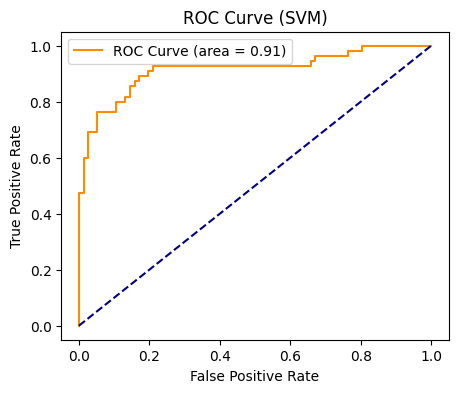

In [ ]:
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
roc_auc_svm = auc(fpr_svm, tpr_svm)

plt.figure(figsize = (5, 4))
plt.plot(fpr_svm, tpr_svm, color = 'darkorange', label = f'ROC Curve (area = {roc_auc_svm:.2f})')
plt.plot([0, 1], [0, 1], color = 'navy', linestyle = '--')
plt.title('ROC Curve (SVM)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()
